<div style="border-left: 5px solid #1f4e79; padding: 16px 20px; background-color: #f8fafc; border: 1px solid #d9e2ec; border-radius: 6px; margin-bottom: 24px; font-family: Arial, sans-serif;">
  <h1 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 28px;">Construction des comparables immobiliers</h1>
  <p style="margin: 0; color: #4b5563; font-size: 15px; line-height: 1.55;">Version V3.1 HTML portfolio  — sélection, scoring et estimation par biens comparables. Ce notebook transforme la base résidentielle enrichie en panels de comparables exploitables pour l’aide à l’estimation immobilière.</p>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Objectif</h3>
  <div style="color: #4b5563; font-size: 14px;">Rôle du notebook dans le pipeline Après les étapes de nettoyage, de rattachement territorial, d’enrichissement et de variables temporelles, ce notebook construit une méthode opérationnelle de comparaison de biens. L’objectif n’est pas de produire une valorisation automatique définitive, mais un cadre d’estimation lisible, contrôlable et explicable.   Entrée : base résidentielle temporelle issue du notebook précédent.  Traitement : filtrage géographique, typologique, surfacique et temporel.  Sortie : base enrichie avec comparables, estimations, indicateurs de confiance et exports de synthèse.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;"></h3>
  <div style="color: #4b5563; font-size: 14px;">Paramétrage des chemins et des sorties Cette cellule définit les chemins d’entrée et de sortie du notebook. Elle fixe la base parquet produite en amont et les fichiers destinés à être transmis à la suite du pipeline.  La logique portfolio rend explicite le contrat de données : ce notebook reçoit une base déjà préparée et restitue une base comparable ainsi que des exports allégés.</div>
</div>

In [6]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

INPUT_PATH = PROCESSED_DIR / "df_biens_residentiels_temporel.parquet"

OUTPUT_PATH = PROCESSED_DIR / "df_biens_residentiels_comparables.parquet"
OUTPUT_LIGHT_PATH = PROCESSED_DIR / "df_biens_residentiels_comparables_light.parquet"

assert INPUT_PATH.exists(), f"Fichier d'entrée introuvable : {INPUT_PATH}"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;"
  <div style="color: #4b5563; font-size: 14px;">Import des librairies et fonctions d’affichage Les librairies mobilisées couvrent les traitements tabulaires, la visualisation statistique et la cartographie interactive. Folium est chargé de manière conditionnelle afin que le notebook reste exécutable même si l’environnement ne dispose pas du module cartographique.  Cette précaution améliore la portabilité du notebook sur Jupyter et GitHub.</div>
</div>

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, IFrame, display

try:
    import folium
    from folium.plugins import MarkerCluster
except ImportError:
    folium = None
    MarkerCluster = None
    print("Folium n'est pas installe. Installez-le avec: pip install folium")

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 120)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["savefig.dpi"] = 140


def save_current_fig(name: str) -> None:
    """Sauvegarde la figure Matplotlib courante puis l'affiche."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, bbox_inches="tight")
    plt.show()



<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;
  <div style="color: #4b5563; font-size: 14px;">Chargement de la base résidentielle temporelle La base chargée contient plus de 3 millions de mutations et 164 variables dans sa version complète. Après sélection des champs utiles aux comparables et filtrage des indicateurs de validité, la base exploitable atteint environ 3,087 millions de lignes et 17 colonnes.  Cette étape confirme que le socle de données est suffisamment large pour construire des panels locaux, tout en concentrant l’analyse sur les variables réellement nécessaires à la comparaison immobilière.</div>
</div>

In [8]:
df = pd.read_parquet(PATH_DF_BASE)
print("Base brute:", df.shape)

required_cols = [
    "id_mutation", "date_mutation", "valeur_fonciere", "prix_m2",
    "surface_reference", "nb_pieces_total", "type_bien",
    "code_iris", "nom_iris", "code_commune", "nom_commune", "code_departement",
    "longitude", "latitude",
    "flag_prix_m2_valide", "flag_surface_reference_valide",
    "typologie_marche_finale",
 ]

avail_cols = [c for c in required_cols if c in df.columns]
comparables = df[avail_cols].copy()

comparables["date_mutation"] = pd.to_datetime(comparables["date_mutation"], errors="coerce")
for c in ["valeur_fonciere", "prix_m2", "surface_reference", "nb_pieces_total", "longitude", "latitude"]:
    if c in comparables.columns:
        comparables[c] = pd.to_numeric(comparables[c], errors="coerce")

if "flag_prix_m2_valide" in comparables.columns:
    comparables = comparables[comparables["flag_prix_m2_valide"] == True].copy()
if "flag_surface_reference_valide" in comparables.columns:
    comparables = comparables[comparables["flag_surface_reference_valide"] == True].copy()

comparables = comparables.dropna(subset=["date_mutation", "prix_m2", "surface_reference", "valeur_fonciere"])
comparables["annee"] = comparables["date_mutation"].dt.year

print("Base comparables propre:", comparables.shape)
display(comparables.head(3))

Base brute: (3090254, 164)
Base comparables propre: (3087309, 17)


,id_mutation,date_mutation,valeur_fonciere,prix_m2,surface_reference,nb_pieces_total,type_bien,code_iris,nom_iris,code_commune,nom_commune,code_departement,longitude,latitude,flag_prix_m2_valide,flag_surface_reference_valide,annee
0,2020-6877,2020-08-04,165000.0,1774.193548,93.0,4.0,Maison,010010000,L'ABERGEMENT-CLEMENCIAT,01001,L'Abergement-Clémenciat,01,4.922602,46.158630,True,True,2020
1,2020-7211,2020-09-28,170000.0,1188.811189,143.0,3.0,Maison,010010000,L'ABERGEMENT-CLEMENCIAT,01001,L'Abergement-Clémenciat,01,4.920435,46.127785,True,True,2020
2,2020-8291,2020-12-17,358100.0,1845.876289,194.0,6.0,Maison,010010000,L'ABERGEMENT-CLEMENCIAT,01001,L'Abergement-Clémenciat,01,4.918594,46.145552,True,True,2020


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Décision analytique</h3>
  <div style="color: #4b5563; font-size: 14px;">Définition du cas pratique de référence Le notebook utilise un cas pratique centré sur Toulouse : appartement de 70 m², 3 pièces, date de référence au 31 décembre 2024. Ce choix sert de point d’ancrage pour tester la méthode sur un exemple urbain lisible.  Le sujet de référence permet de contrôler concrètement l’effet des filtres et du scoring : chaque comparable est évalué relativement à ce bien théorique.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Explication</h3>
  <div style="color: #4b5563; font-size: 14px;">Fonctions utilitaires de normalisation et de distance Les fonctions définies ici sécurisent les conversions numériques, normalisent les distances et calculent les écarts entre biens. Elles constituent la couche méthodologique du scoring des comparables.  La normalisation robuste limite l’influence des valeurs extrêmes en utilisant une winsorisation implicite aux quantiles 5 % et 95 %.</div>
</div>

In [ ]:
#  SELECTION DE LA VILLE 
VILLE_SELECTIONNEE = "Toulouse"
# Options: Toulouse, Nice, Lille, Nantes, Bordeaux, Rennes, Montpellier, Le Havre, Saint-Étienne, Reims

ville_configs = {
    "Toulouse": {"type_bien": "Appartement", "surface_reference": 70.0, "nb_pieces_total": 3.0},
    "Nice": {"type_bien": "Appartement", "surface_reference": 60.0, "nb_pieces_total": 2.0},
    "Lille": {"type_bien": "Appartement", "surface_reference": 75.0, "nb_pieces_total": 3.0},
    "Nantes": {"type_bien": "Appartement", "surface_reference": 65.0, "nb_pieces_total": 3.0},
    "Bordeaux": {"type_bien": "Appartement", "surface_reference": 70.0, "nb_pieces_total": 3.0},
    "Rennes": {"type_bien": "Appartement", "surface_reference": 65.0, "nb_pieces_total": 2.0},
    "Montpellier": {"type_bien": "Appartement", "surface_reference": 60.0, "nb_pieces_total": 2.0},
    "Le Havre": {"type_bien": "Appartement", "surface_reference": 55.0, "nb_pieces_total": 2.0},
    "Saint-Étienne": {"type_bien": "Appartement", "surface_reference": 50.0, "nb_pieces_total": 2.0},
    "Reims": {"type_bien": "Appartement", "surface_reference": 60.0, "nb_pieces_total": 2.0},
}

config = ville_configs.get(VILLE_SELECTIONNEE, ville_configs["Toulouse"])

subject = {
    "nom_commune": VILLE_SELECTIONNEE,
    "code_commune": None,
    "code_iris": None,
    "type_bien": config["type_bien"],
    "surface_reference": config["surface_reference"],
    "nb_pieces_total": config["nb_pieces_total"],
    "date_mutation": "2024-12-31",
    "prix_m2_reel": None,
    "longitude": None,
    "latitude": None,
    "typologie_marche_finale": None,
}

subject_table = pd.DataFrame([
    {"champ": "type_bien", "valeur": subject["type_bien"]},
    {"champ": "surface_reference", "valeur": subject["surface_reference"]},
    {"champ": "nb_pieces_total", "valeur": subject["nb_pieces_total"]},
    {"champ": "localisation", "valeur": subject["nom_commune"]},
    {"champ": "date_reference", "valeur": subject["date_mutation"]},
])

print(f"=== CAS PRATIQUE: {VILLE_SELECTIONNEE} ===")
print("Ce bien sert de reference pour la selection des comparables.")
display(subject_table)

=== CAS PRATIQUE: Toulouse ===
Ce bien sert de reference pour la selection des comparables.


,champ,valeur
0,type_bien,Appartement
1,surface_reference,70.0
2,nb_pieces_total,3.0
3,localisation,Toulouse
4,date_reference,2024-12-31


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des résultats</h3>
  <div style="color: #4b5563; font-size: 14px;">Filtrage progressif du panel de comparables Le filtrage réduit la base nationale de 3,087 millions de biens à 2 409 comparables potentiels pour Toulouse. La chute la plus forte vient du filtre géographique, qui isole la commune avant d’appliquer les contraintes de type, de surface et de période.  Cette réduction est cohérente : elle améliore la proximité métier du panel sans imposer immédiatement une sélection trop restrictive.</div>
</div>

In [10]:
def safe_num(s):
    """Convertit une serie en numerique en forcant les valeurs invalides a NaN."""
    return pd.to_numeric(s, errors="coerce")


def robust_minmax(x):
    """Normalise une serie entre 0 et 1 apres winsorisation aux quantiles 5% et 95%."""
    s = safe_num(x).replace([np.inf, -np.inf], np.nan)
    if s.notna().sum() == 0:
        return pd.Series(np.nan, index=s.index)

    p05, p95 = s.quantile(0.05), s.quantile(0.95)
    s = s.clip(lower=p05, upper=p95)

    if p95 == p05:
        return pd.Series(0.0, index=s.index)
    return (s - p05) / (p95 - p05)


def relative_abs_diff(series, ref):
    """Calcule un ecart relatif absolu entre une serie et une valeur de reference."""
    s = safe_num(series)
    r = pd.to_numeric(pd.Series([ref]), errors="coerce").iloc[0]

    # Fallback robuste si la reference est absente ou nulle.
    if pd.isna(r) or r == 0:
        r = s.median()
    if pd.isna(r) or r == 0:
        r = 1.0

    return (s - r).abs() / abs(r)


def km_distance(lon1, lat1, lon2, lat2):
    """Approxime une distance en kilometres entre deux points longitude/latitude."""
    if any(pd.isna([lon1, lat1, lon2, lat2])):
        return np.nan

    dx = (lon1 - lon2) * 111.32 * np.cos(np.radians((lat1 + lat2) / 2.0))
    dy = (lat1 - lat2) * 110.57
    return float(np.sqrt(dx**2 + dy**2))


def weighted_mean(values, weights):
    """Calcule une moyenne ponderee en ignorant les valeurs ou poids non exploitables."""
    v = safe_num(values)
    w = safe_num(weights)
    mask = v.notna() & w.notna() & (w > 0)

    if mask.sum() == 0:
        return np.nan
    return np.average(v[mask], weights=w[mask])



<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des résultats</h3>
  <div style="color: #4b5563; font-size: 14px;">Distribution des prix du panel filtré Le panel toulousain filtré présente une médiane proche de 2 666 €/m² et un intervalle interquartile d’environ 1 370 €/m², soit une dispersion relative proche de 51 %.  Cette dispersion montre que le marché local reste hétérogène même après filtrage. L’estimation doit donc s’appuyer sur un classement plus fin des biens, et non sur une simple moyenne communale.</div>
</div>

In [11]:
dt_ref = pd.Timestamp(subject["date_mutation"])

panel_step0 = comparables.copy()
progress_rows = [{"etape": "depart", "nb_biens": len(panel_step0), "impact_vs_prec_pct": np.nan}]

# 1) Filtre geographique
panel_geo = panel_step0.copy()
geo_rule = "aucun"
if subject.get("code_iris") is not None and "code_iris" in panel_geo.columns:
    panel_geo = panel_geo[panel_geo["code_iris"] == subject["code_iris"]].copy()
    geo_rule = "code_iris"
elif subject.get("code_commune") is not None and "code_commune" in panel_geo.columns:
    panel_geo = panel_geo[panel_geo["code_commune"] == subject["code_commune"]].copy()
    geo_rule = "code_commune"
elif subject.get("nom_commune") is not None and "nom_commune" in panel_geo.columns:
    panel_geo = panel_geo[panel_geo["nom_commune"] == subject["nom_commune"]].copy()
    geo_rule = "nom_commune"

impact_geo = 100 * (len(panel_geo) - len(panel_step0)) / max(len(panel_step0), 1)
progress_rows.append({"etape": f"filtre_geo ({geo_rule})", "nb_biens": len(panel_geo), "impact_vs_prec_pct": impact_geo})

# 2) Filtre type de bien
panel_type = panel_geo.copy()
if subject.get("type_bien") is not None and "type_bien" in panel_type.columns:
    panel_type = panel_type[panel_type["type_bien"] == subject["type_bien"]].copy()
impact_type = 100 * (len(panel_type) - len(panel_geo)) / max(len(panel_geo), 1)
progress_rows.append({"etape": "filtre_type_bien", "nb_biens": len(panel_type), "impact_vs_prec_pct": impact_type})

# 3) Filtre surface
panel_surface = panel_type.copy()
s_ref = subject.get("surface_reference")
if s_ref is not None and "surface_reference" in panel_surface.columns:
    panel_surface = panel_surface[
        panel_surface["surface_reference"].between(s_ref * 0.70, s_ref * 1.30)
    ].copy()
impact_surface = 100 * (len(panel_surface) - len(panel_type)) / max(len(panel_type), 1)
progress_rows.append({"etape": "filtre_surface (+/-30%)", "nb_biens": len(panel_surface), "impact_vs_prec_pct": impact_surface})

# 4) Filtre temporalite
panel_time = panel_surface.copy()
panel_time = panel_time[
    panel_time["date_mutation"].between(dt_ref - pd.DateOffset(months=24), dt_ref)
].copy()
impact_time = 100 * (len(panel_time) - len(panel_surface)) / max(len(panel_surface), 1)
progress_rows.append({"etape": "filtre_temps (24 mois)", "nb_biens": len(panel_time), "impact_vs_prec_pct": impact_time})

# Elargissement progressif si panel trop faible
panel = panel_time.copy()
if len(panel) < 40:
    panel = panel_surface[
        panel_surface["date_mutation"].between(dt_ref - pd.DateOffset(months=36), dt_ref)
    ].copy()
    progress_rows.append({
        "etape": "elargissement_temps (36 mois)",
        "nb_biens": len(panel),
        "impact_vs_prec_pct": 100 * (len(panel) - len(panel_time)) / max(len(panel_time), 1),
    })
if len(panel) < 25:
    panel = panel_type[
        panel_type["date_mutation"].between(dt_ref - pd.DateOffset(months=48), dt_ref)
    ].copy()
    progress_rows.append({
        "etape": "elargissement_temps (48 mois)",
        "nb_biens": len(panel),
        "impact_vs_prec_pct": 100 * (len(panel) - progress_rows[-1]["nb_biens"]) / max(progress_rows[-1]["nb_biens"], 1),
    })

prefilter_progress = pd.DataFrame(progress_rows)

print("Nombre de comparables apres filtrage progressif:", len(panel))
print("Chaque filtre reduit le panel mais ameliore la pertinence.")
display(prefilter_progress)
display(panel.head(3))

Nombre de comparables apres filtrage progressif: 2409
Chaque filtre reduit le panel mais ameliore la pertinence.


,etape,nb_biens,impact_vs_prec_pct
0,depart,3087309,NaN
1,filtre_geo (nom_commune),22878,-99.258966
2,filtre_type_bien,17346,-24.180435
3,filtre_surface (+/-30%),6110,-64.775741
4,filtre_temps (24 mois),2409,-60.572831


,id_mutation,date_mutation,valeur_fonciere,prix_m2,surface_reference,nb_pieces_total,type_bien,code_iris,nom_iris,code_commune,nom_commune,code_departement,longitude,latitude,flag_prix_m2_valide,flag_surface_reference_valide,annee
847705,2023-372084,2023-01-16,304700.0,4223.731633,72.14,2.0,Appartement,315550101,JACOBINS,31555,Toulouse,31,1.441674,43.601090,True,True,2023
847708,2023-376114,2023-03-21,230600.0,2811.509388,82.02,3.0,Appartement,315550101,JACOBINS,31555,Toulouse,31,1.438521,43.602270,True,True,2023
847709,2023-378374,2023-05-12,235000.0,2876.376989,81.70,2.0,Appartement,315550101,JACOBINS,31555,Toulouse,31,1.436483,43.603047,True,True,2023


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Décision analytique</h3>
  <div style="color: #4b5563; font-size: 14px;">Construction des distances entre sujet et comparables Chaque bien du panel est comparé au sujet selon quatre dimensions : surface, nombre de pièces, temporalité et localisation. Ces distances traduisent la proximité métier entre le bien cible et les transactions observées.  Cette étape rend le modèle explicable : un comparable n’est pas seulement proche par son prix, il doit aussi être proche par ses caractéristiques et son contexte.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Décision analytique</h3>
  <div style="color: #4b5563; font-size: 14px;">Score global de comparabilité Le score global combine les distances normalisées avec des poids métier : 35 % pour la surface, 20 % pour les pièces, 25 % pour le temps et 20 % pour la géographie.  Les premiers biens classés ont des scores proches de 0,10, ce qui signale une forte proximité selon les critères retenus. Le score reste toutefois un outil de hiérarchisation, pas une preuve de valeur.</div>
</div>

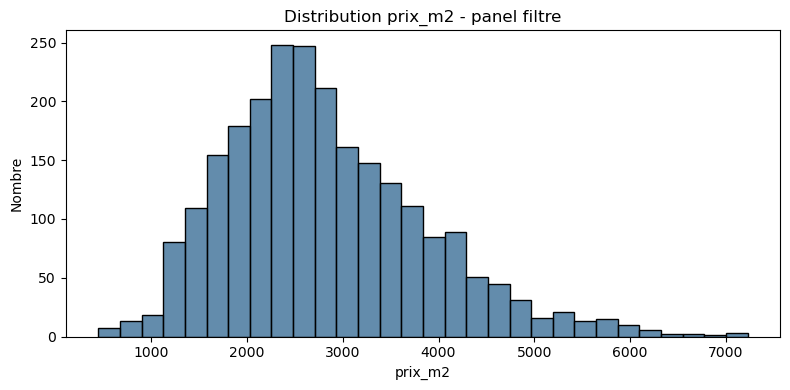

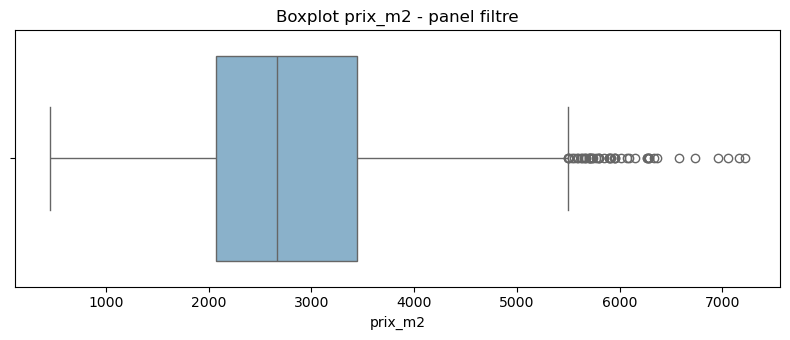

Le panel presente une dispersion de 1370 €/m² (IQR).


,n_panel,prix_m2_q25,prix_m2_mediane,prix_m2_q75,iqr,dispersion_relative
0,2409,2073.897497,2666.284404,3444.354184,1370.456687,0.513995


In [12]:
panel_stats = pd.DataFrame()
if panel.empty:
    print("Panel vide apres filtrage.")
else:
    p = pd.to_numeric(panel["prix_m2"], errors="coerce").dropna()
    q25, q50, q75 = p.quantile([0.25, 0.50, 0.75])
    iqr = q75 - q25
    panel_stats = pd.DataFrame([{
        "n_panel": len(panel),
        "prix_m2_q25": q25,
        "prix_m2_mediane": q50,
        "prix_m2_q75": q75,
        "iqr": iqr,
        "dispersion_relative": iqr / q50 if q50 else np.nan,
    }])

    plt.figure(figsize=(8, 4))
    sns.histplot(p, bins=30, color="#2F6690")
    plt.title("Distribution prix_m2 - panel filtre")
    plt.xlabel("prix_m2")
    plt.ylabel("Nombre")
    save_current_fig("comparables_panel_hist_prix_m2.png")

    plt.figure(figsize=(8, 3.5))
    sns.boxplot(x=p, color="#7FB3D5")
    plt.title("Boxplot prix_m2 - panel filtre")
    plt.xlabel("prix_m2")
    save_current_fig("comparables_panel_boxplot_prix_m2.png")

    print(f"Le panel presente une dispersion de {iqr:.0f} €/m² (IQR).")

display(panel_stats)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des résultats</h3>
  <div style="color: #4b5563; font-size: 14px;">Sélection stricte, élargie et finale Trois niveaux de panels sont construits : strict, élargi et retenu. Le panel final conserve 25 comparables pour l’estimation.  La médiane des 25 comparables retenus atteint environ 2 973 €/m², supérieure à celle du panel filtré global. Cela traduit l’effet du score : les biens les plus proches ne reproduisent pas nécessairement la distribution moyenne du marché local.</div>
</div>

In [13]:
panel_dist = panel.copy()
if panel_dist.empty:
    print("Panel vide: impossible de construire les distances.")
else:
    dt_ref = pd.Timestamp(subject["date_mutation"])

    panel_dist["distance_surface"] = relative_abs_diff(panel_dist["surface_reference"], subject.get("surface_reference"))

    if "nb_pieces_total" in panel_dist.columns and subject.get("nb_pieces_total") is not None:
        panel_dist["distance_pieces"] = (pd.to_numeric(panel_dist["nb_pieces_total"], errors="coerce") - subject.get("nb_pieces_total")).abs()
    else:
        panel_dist["distance_pieces"] = np.nan

    panel_dist["distance_temps"] = (panel_dist["date_mutation"] - dt_ref).dt.days.abs()

    if all(subject.get(k) is not None for k in ["longitude", "latitude"]) and {"longitude", "latitude"}.issubset(panel_dist.columns):
        panel_dist["distance_geographique"] = panel_dist.apply(
            lambda r: km_distance(subject["longitude"], subject["latitude"], r.get("longitude"), r.get("latitude")),
            axis=1,
        )
    else:
        panel_dist["distance_geographique"] = np.nan

    print("Cette distance_surface mesure l'ecart relatif de surface.")
    print("Cette distance_pieces mesure l'ecart en nombre de pieces.")
    print("Cette distance_temps mesure l'ecart en jours avec la date de reference.")
    print("Cette distance_geographique mesure l'ecart spatial (km) si coordonnees disponibles.")

display(panel_dist[[c for c in ["id_mutation", "prix_m2", "distance_surface", "distance_pieces", "distance_temps", "distance_geographique"] if c in panel_dist.columns]].head(10))

Cette distance_surface mesure l'ecart relatif de surface.
Cette distance_pieces mesure l'ecart en nombre de pieces.
Cette distance_temps mesure l'ecart en jours avec la date de reference.
Cette distance_geographique mesure l'ecart spatial (km) si coordonnees disponibles.


,id_mutation,prix_m2,distance_surface,distance_pieces,distance_temps,distance_geographique
847705,2023-372084,4223.731633,0.030571,1.0,715,NaN
847708,2023-376114,2811.509388,0.171714,0.0,651,NaN
847709,2023-378374,2876.376989,0.167143,1.0,599,NaN
847711,2023-384486,2839.646824,0.003143,1.0,490,NaN
847712,2023-384597,2871.171771,0.141714,1.0,488,NaN
847714,2023-385467,6735.426640,0.014571,1.0,484,NaN
847719,2023-389228,3089.193440,0.271714,1.0,403,NaN
847720,2023-389569,4569.788401,0.270857,1.0,396,NaN
847724,2024-333444,2454.991817,0.047429,2.0,355,NaN
847726,2024-334332,3626.243886,0.153000,0.0,341,NaN


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des résultats</h3>
  <div style="color: #4b5563; font-size: 14px;">Estimation par les comparables retenus Sur la base des 25 comparables retenus et d’une surface cible de 70 m², l’estimation médiane ressort à environ 208 095 €. La fourchette interquartile va d’environ 154 269 € à 290 261 €.  Cette fourchette doit être lue comme un encadrement empirique. Elle reflète à la fois la dispersion des prix observés et la profondeur du panel final.</div>
</div>

In [14]:
if panel_dist.empty:
    panel_scored = panel_dist.copy()
    score_weights = pd.DataFrame()
else:
    panel_scored = panel_dist.copy()

    panel_scored["n_surface"] = robust_minmax(panel_scored["distance_surface"]).fillna(0.5)
    panel_scored["n_pieces"] = robust_minmax(panel_scored["distance_pieces"]).fillna(0.5)
    panel_scored["n_temps"] = robust_minmax(panel_scored["distance_temps"]).fillna(0.5)
    panel_scored["n_geo"] = robust_minmax(panel_scored["distance_geographique"]).fillna(0.5)

    # Ponderations explicites.
    w_surface = 0.35
    w_pieces = 0.20
    w_temps = 0.25
    w_geo = 0.20

    panel_scored["score_global"] = (
        w_surface * panel_scored["n_surface"]
        + w_pieces * panel_scored["n_pieces"]
        + w_temps * panel_scored["n_temps"]
        + w_geo * panel_scored["n_geo"]
    )

    score_weights = pd.DataFrame([
        {"dimension": "surface", "poids": w_surface},
        {"dimension": "pieces", "poids": w_pieces},
        {"dimension": "temps", "poids": w_temps},
        {"dimension": "geographie", "poids": w_geo},
    ])

    panel_scored = panel_scored.sort_values("score_global", ascending=True).copy()

print("Le score permet de hierarchiser les comparables, mais ne remplace pas l'analyse.")
display(score_weights)
display(panel_scored[[c for c in ["id_mutation", "prix_m2", "score_global", "n_surface", "n_pieces", "n_temps", "n_geo"] if c in panel_scored.columns]].head(15))

Le score permet de hierarchiser les comparables, mais ne remplace pas l'analyse.


,dimension,poids
0,surface,0.35
1,pieces,0.20
2,temps,0.25
3,geographie,0.20


,id_mutation,prix_m2,score_global,n_surface,n_pieces,n_temps,n_geo
863961,2024-352302,1997.116078,0.100000,0.000000,0.0,0.000000,0.5
856053,2024-351747,2423.340069,0.100000,0.000000,0.0,0.000000,0.5
867604,2024-350527,3563.791875,0.100000,0.000000,0.0,0.000000,0.5
863476,2024-352538,2007.230658,0.100000,0.000000,0.0,0.000000,0.5
861012,2024-350454,2182.284981,0.100000,0.000000,0.0,0.000000,0.5
849007,2024-351932,4265.091864,0.104253,0.012152,0.0,0.000000,0.5
858587,2024-350165,4270.134228,0.106135,0.017529,0.0,0.000000,0.5
853043,2024-349593,3079.994172,0.106302,0.009463,0.0,0.011958,0.5
847983,2024-348889,4755.200226,0.107848,0.000000,0.0,0.031390,0.5
852636,2024-351802,2972.784368,0.108582,0.024519,0.0,0.000000,0.5


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des résultats</h3>
  <div style="color: #4b5563; font-size: 14px;">Niveau de confiance de l’estimation Le niveau de confiance ressort comme élevé, avec un score de 6. La fraîcheur médiane des comparables est de 42 jours, ce qui renforce la pertinence temporelle du panel.  La dispersion relative reste toutefois importante, autour de 65 %. Le signal est exploitable, mais il doit être accompagné d’une réserve sur les attributs non observés : étage, état, exposition, prestations ou micro-localisation.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des résultats</h3>
  <div style="color: #4b5563; font-size: 14px;">Visualisations du panel retenu Les graphiques rendent visible la distribution des prix, la relation surface/prix au mètre carré et la position du sujet par rapport aux comparables.  Ces sorties permettent de contrôler visuellement la cohérence de la sélection et d’identifier une éventuelle asymétrie, des valeurs atypiques ou une concentration excessive du panel.</div>
</div>

In [15]:
if panel_scored.empty:
    comparables_stricts = panel_scored.copy()
    comparables_elargis = panel_scored.copy()
    comparables_retenus = panel_scored.copy()
    comparables_levels = pd.DataFrame()
else:
    comparables_stricts = panel_scored[panel_scored["score_global"] <= panel_scored["score_global"].quantile(0.30)].copy()
    comparables_elargis = panel_scored[panel_scored["score_global"] <= panel_scored["score_global"].quantile(0.60)].copy()
    comparables_retenus = panel_scored.head(25).copy()

    def level_stats(name, d):
        if d.empty:
            return {"niveau": name, "n": 0, "prix_m2_median": np.nan, "iqr": np.nan}
        p = pd.to_numeric(d["prix_m2"], errors="coerce").dropna()
        return {
            "niveau": name,
            "n": int(len(d)),
            "prix_m2_median": float(p.median()) if len(p) else np.nan,
            "iqr": float(p.quantile(0.75) - p.quantile(0.25)) if len(p) else np.nan,
        }

    comparables_levels = pd.DataFrame([
        level_stats("stricts", comparables_stricts),
        level_stats("elargis", comparables_elargis),
        level_stats("retenus", comparables_retenus),
    ])

best_comparables = comparables_retenus.copy()

display(comparables_levels)
print("Comparables retenus pour estimation:", len(best_comparables))

,niveau,n,prix_m2_median,iqr
0,stricts,723,2812.755519,1265.587628
1,elargis,1445,2767.489712,1313.959208
2,retenus,25,2972.784368,1942.752641


Comparables retenus pour estimation: 25


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Section principale</h3>
  <div style="color: #4b5563; font-size: 14px;">Cartographie des comparables du cas pratique La carte Folium localise les comparables retenus pour Toulouse. Elle complète l’analyse tabulaire en donnant une lecture spatiale du panel.  Cette visualisation est importante pour un usage métier : deux biens proches statistiquement peuvent rester différents si leur localisation fine diverge fortement.</div>
</div>

In [16]:
if best_comparables.empty or subject.get("surface_reference") is None:
    estimation = pd.DataFrame()
else:
    p = pd.to_numeric(best_comparables["prix_m2"], errors="coerce").dropna()
    surf = float(subject["surface_reference"])

    prix_m2_med = p.median()
    prix_m2_q25 = p.quantile(0.25)
    prix_m2_q75 = p.quantile(0.75)

    estimation = pd.DataFrame([{
        "n_comparables": len(best_comparables),
        "surface_sujet": surf,
        "prix_m2_mediane": prix_m2_med,
        "prix_m2_q25": prix_m2_q25,
        "prix_m2_q75": prix_m2_q75,
        "estimation_basse": prix_m2_q25 * surf,
        "estimation_mediane": prix_m2_med * surf,
        "estimation_haute": prix_m2_q75 * surf,
    }])

    print("Le bien se situe probablement dans cette fourchette basse-mediane-haute.")

display(estimation)

Le bien se situe probablement dans cette fourchette basse-mediane-haute.


,n_comparables,surface_sujet,prix_m2_mediane,prix_m2_q25,prix_m2_q75,estimation_basse,estimation_mediane,estimation_haute
0,25,70.0,2972.784368,2203.838102,4146.590743,154268.667132,208094.905792,290261.352022


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Section principale</h3>
  <div style="color: #4b5563; font-size: 14px;">Extension de la méthode aux grandes villes Le notebook généralise ensuite la méthode à un ensemble de grandes villes. Les configurations de biens de référence sont adaptées selon les marchés afin de tester la robustesse de la logique de comparables.  Les résultats montrent des niveaux de prix différenciés : Paris et Nice ressortent parmi les marchés les plus élevés, tandis que Montpellier et Toulouse présentent des médianes plus modérées dans les cas testés.</div>
</div>

In [17]:
if best_comparables.empty:
    confidence_detail = pd.DataFrame()
else:
    p = pd.to_numeric(best_comparables["prix_m2"], errors="coerce").dropna()
    iqr = p.quantile(0.75) - p.quantile(0.25) if len(p) else np.nan
    disp_rel = iqr / p.median() if len(p) and p.median() else np.nan

    proximite_med = pd.to_numeric(best_comparables["score_global"], errors="coerce").median()
    fraicheur_med_j = (pd.Timestamp(subject["date_mutation"]) - best_comparables["date_mutation"]).dt.days.abs().median()

    s_n = 2 if len(best_comparables) >= 25 else (1 if len(best_comparables) >= 12 else 0)
    s_disp = 2 if pd.notna(disp_rel) and disp_rel < 0.18 else (1 if pd.notna(disp_rel) and disp_rel < 0.30 else 0)
    s_prox = 2 if pd.notna(proximite_med) and proximite_med < 0.35 else (1 if pd.notna(proximite_med) and proximite_med < 0.55 else 0)
    s_fresh = 2 if pd.notna(fraicheur_med_j) and fraicheur_med_j <= 180 else (1 if pd.notna(fraicheur_med_j) and fraicheur_med_j <= 365 else 0)

    score_conf = s_n + s_disp + s_prox + s_fresh
    confidence_level = "eleve" if score_conf >= 6 else ("moyen" if score_conf >= 3 else "faible")

    confidence_detail = pd.DataFrame([{
        "n_comparables": len(best_comparables),
        "dispersion_relative": disp_rel,
        "proximite_mediane_score": proximite_med,
        "fraicheur_mediane_jours": fraicheur_med_j,
        "score_confiance": score_conf,
        "niveau_confiance": confidence_level,
    }])

display(confidence_detail)
print("La confiance depend de la qualite du panel.")

,n_comparables,dispersion_relative,proximite_mediane_score,fraicheur_mediane_jours,score_confiance,niveau_confiance
0,25,0.653513,0.118876,42.0,6,eleve


La confiance depend de la qualite du panel.


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Limites</h3>
  <div style="color: #4b5563; font-size: 14px;">Disponibilité cartographique et couverture locale La synthèse multi-villes indique que Strasbourg ne dispose pas de comparables exploitables dans cette configuration, ce qui empêche la génération de carte. Les autres villes produisent chacune 25 comparables et une carte possible.  Cette limite est méthodologiquement importante : l’absence de résultat signale une contrainte de données ou de filtrage qui doit être documentée avant toute interprétation métier.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des résultats</h3>
  <div style="color: #4b5563; font-size: 14px;">Affichage interactif des cartes L’affichage des cartes permet de parcourir les panels ville par ville. Cette étape sert davantage à la vérification qualitative qu’à la production d’un indicateur chiffré.  Dans une logique portfolio, elle démontre la capacité du pipeline à associer scoring tabulaire et restitution géographique interactive.</div>
</div>

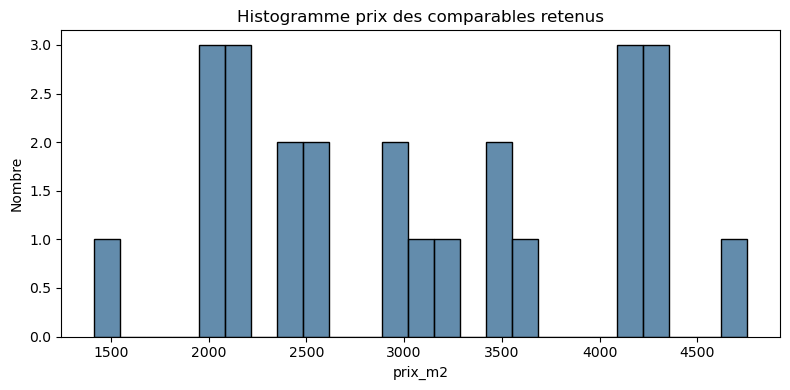

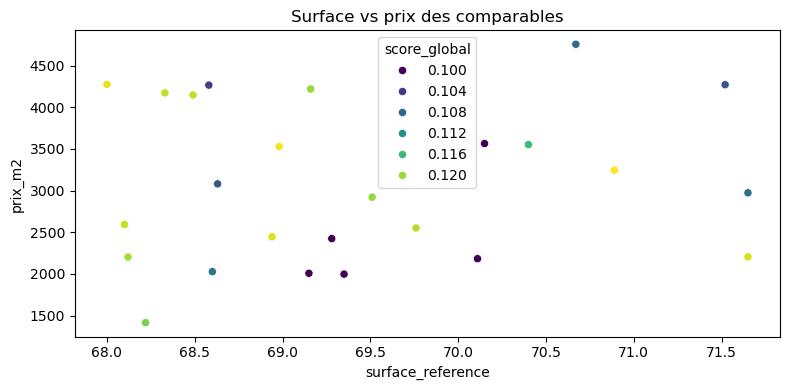

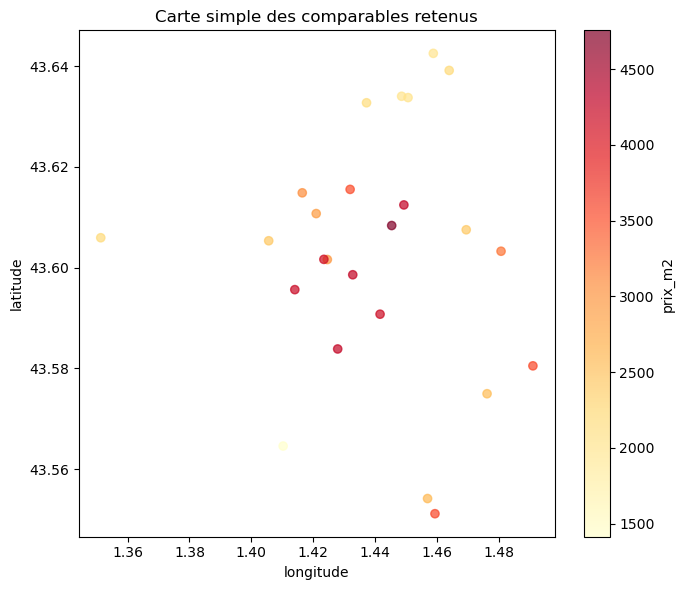

Visualisations generees pour rendre la selection des comparables visible.


In [18]:
if not best_comparables.empty:
    # Distribution des prix/m2 des comparables retenus.
    plt.figure(figsize=(8, 4))
    sns.histplot(best_comparables["prix_m2"].dropna(), bins=25, color="#2F6690")
    plt.title("Histogramme prix des comparables retenus")
    plt.xlabel("prix_m2")
    plt.ylabel("Nombre")
    save_current_fig("comparables_histogramme_prix.png")

    # Relation surface / prix_m2, coloree par score de similarite.
    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=best_comparables, x="surface_reference", y="prix_m2", hue="score_global", palette="viridis", s=35)
    plt.title("Surface vs prix des comparables")
    plt.xlabel("surface_reference")
    plt.ylabel("prix_m2")
    save_current_fig("comparables_scatter_surface_prix.png")

    # Carte statique de controle rapide.
    if {"longitude", "latitude"}.issubset(best_comparables.columns):
        geo_plot = best_comparables.dropna(subset=["longitude", "latitude"]).copy()
        if not geo_plot.empty:
            plt.figure(figsize=(7, 6))
            sc = plt.scatter(geo_plot["longitude"], geo_plot["latitude"], c=geo_plot["prix_m2"], cmap="YlOrRd", alpha=0.7)
            plt.colorbar(sc, label="prix_m2")
            plt.title("Carte simple des comparables retenus")
            plt.xlabel("longitude")
            plt.ylabel("latitude")
            save_current_fig("comparables_carte_points_prix.png")

print("Visualisations generees pour rendre la selection des comparables visible.")



<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires automatiques dans UNE seule cellule (Jupyter)</h3>
  <div style="color: #4b5563; font-size: 14px;">À adapter selon les noms exacts de tes variables/dataframes commentaire = f""" Analyse rapide des comparables retenus : Distribution des prix au m² Les prix au m² présentent une forte dispersion (~1400 à ~4800 €/m²). Deux groupes semblent apparaître : • un segment intermédiaire autour de 2000–3500 €/m² • un segment haut > 4000 €/m² Quelques valeurs atypiques peuvent influencer la moyenne. Relation surface / prix Les surfaces sont relativement homogènes (~68 à 72 m²). Malgré cela, le prix au m² varie fortement. La surface seule n’explique donc pas les écarts de valorisation. D’autres facteurs jouent probablement un rôle : • localisation micro • état du bien • prestations • étage / vue / extérieur Répartition géographique Les comparables sont spatialement concentrés. Certaines zones affichent des niveaux de prix plus élevés. Une logique de micro-marché semble apparaître localement. Qualité des comparables Les scores globaux restent proches les uns des autres. Le panel paraît cohérent mais hétérogène sur les prix. Un filtrage complémentaire pourrait être pertinent : • exclusion des extrêmes • segmentation géographique • clustering des biens similaires Conclusion : Le jeu de comparables est exploitable mais présente une variabilité importante des prix au m². Une segmentation plus fine pourrait améliorer la robustesse de l’estimation.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Conclusion</h3>
  <div style="color: #4b5563; font-size: 14px;">Synthèse métier des comparables La synthèse métier formalise les enseignements principaux : estimation médiane autour de 208 k€ pour le cas toulousain, niveau de confiance élevé, mais limites liées aux attributs non observés et à la profondeur locale du marché.  Cette conclusion prépare la transmission des résultats vers les notebooks suivants, où les variables construites pourront alimenter des analyses de segmentation, de restitution ou de modélisation.</div>
</div>

In [19]:
def build_comparables_map(data: pd.DataFrame, city_name: str, output_path: Path | None = None, max_points: int = 300):
    """Construit une carte Folium des comparables d'une ville."""
    if folium is None:
        print("Folium indisponible: carte non generee.")
        return None

    required_geo_cols = {"latitude", "longitude"}
    if data.empty or not required_geo_cols.issubset(data.columns):
        print(f"Carte impossible pour {city_name}: coordonnées absentes ou données vides.")
        return None

    geo = data.dropna(subset=["latitude", "longitude"]).copy()
    if geo.empty:
        print(f"Carte impossible pour {city_name}: aucune coordonnée exploitable.")
        return None

    # Les meilleurs scores sont affiches en priorite pour conserver une carte reactive.
    geo = geo.sort_values("score_global", ascending=True).head(max_points) if "score_global" in geo.columns else geo.head(max_points)

    center = [geo["latitude"].median(), geo["longitude"].median()]
    fmap = folium.Map(
        location=center,
        zoom_start=12,
        tiles="OpenStreetMap",
        control_scale=True,
    )
    cluster = MarkerCluster(name="Comparables retenus").add_to(fmap) if MarkerCluster else fmap

    for _, row in geo.iterrows():
        prix_m2 = row.get("prix_m2", np.nan)
        score = row.get("score_global", np.nan)
        surface = row.get("surface_reference", np.nan)
        date_mut = row.get("date_mutation", "")
        popup_html = f"""
        <b>{city_name}</b><br>
        Prix/m2: {prix_m2:,.0f} €<br>
        Surface: {surface:,.1f} m2<br>
        Score: {score:.3f}<br>
        Date: {date_mut}
        """
        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=5,
            fill=True,
            fill_opacity=0.75,
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=f"{city_name} | {prix_m2:,.0f} €/m²",
        ).add_to(cluster)

    folium.LayerControl().add_to(fmap)
    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fmap.save(str(output_path))
        print("Carte Folium sauvegardée:", output_path)
    return fmap


selected_city_map = build_comparables_map(
    best_comparables,
    VILLE_SELECTIONNEE,
    output_path=FIG_DIR / f"carte_folium_{VILLE_SELECTIONNEE.lower().replace(' ', '_')}.html",
)
selected_city_map



Carte Folium sauvegardée: C:\Users\club_\OneDrive\13_DOCUMENT\000_DATA\dvf_compagnon\outputs_notebook_comparables_cas_pratique\figures\carte_folium_toulouse.html


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Conclusion</h3>
  <div style="color: #4b5563; font-size: 14px;">Exports et transmission au pipeline suivant Les exports enregistrent les principaux résultats de l’approche par comparables : panel retenu, estimation médiane, borne basse, borne haute, niveau de confiance et limites d’interprétation.  La sortie transmise au notebook suivant est donc enrichie d’un signal métier directement exploitable : une estimation empirique encadrée, accompagnée d’un indicateur de qualité et de réserves explicites.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Limites</h3>
  <div style="color: #4b5563; font-size: 14px;">Points de vigilance méthodologiques La méthode par comparables dépend fortement de la qualité des variables disponibles, de la profondeur locale du marché et du choix des pondérations. Elle ne capte pas certains facteurs décisifs comme l’état du bien, l’étage, les travaux, l’exposition, les nuisances ou les prestations.  Le score doit donc être interprété comme un outil d’aide à la décision. Il structure l’analyse, mais ne remplace ni l’expertise locale ni une validation terrain.</div>
</div>

In [20]:
import unicodedata
from pathlib import Path
from IPython.display import HTML, display

TOP_10_VILLES = [
    "Paris",
    "Marseille",
    "Lyon",
    "Toulouse",
    "Nice",
    "Nantes",
    "Montpellier",
    "Strasbourg",
    "Bordeaux",
    "Lille",
]

ville_configs = {
    "Paris": {"type_bien": "Appartement", "surface_reference": 55.0, "nb_pieces_total": 2.0},
    "Marseille": {"type_bien": "Appartement", "surface_reference": 65.0, "nb_pieces_total": 3.0},
    "Lyon": {"type_bien": "Appartement", "surface_reference": 65.0, "nb_pieces_total": 3.0},
    "Toulouse": {"type_bien": "Appartement", "surface_reference": 70.0, "nb_pieces_total": 3.0},
    "Nice": {"type_bien": "Appartement", "surface_reference": 60.0, "nb_pieces_total": 2.0},
    "Nantes": {"type_bien": "Appartement", "surface_reference": 65.0, "nb_pieces_total": 3.0},
    "Montpellier": {"type_bien": "Appartement", "surface_reference": 60.0, "nb_pieces_total": 2.0},
    "Strasbourg": {"type_bien": "Appartement", "surface_reference": 65.0, "nb_pieces_total": 3.0},
    "Bordeaux": {"type_bien": "Appartement", "surface_reference": 70.0, "nb_pieces_total": 3.0},
    "Lille": {"type_bien": "Appartement", "surface_reference": 75.0, "nb_pieces_total": 3.0},
}


def normaliser_nom_commune(value):
    """Normalise un nom de commune pour faciliter les correspondances."""
    if pd.isna(value):
        return ""
    value = str(value).strip().upper()
    value = unicodedata.normalize("NFKD", value)
    value = "".join(ch for ch in value if not unicodedata.combining(ch))
    return value


def filter_city(base: pd.DataFrame, city_name: str) -> pd.DataFrame:
    """Filtre une ville avec gestion des arrondissements pour Paris, Marseille et Lyon."""
    if "nom_commune" not in base.columns:
        return base.copy()

    work = base.copy()
    city_norm = normaliser_nom_commune(city_name)
    commune_norm = work["nom_commune"].map(normaliser_nom_commune)

    if city_norm in {"PARIS", "MARSEILLE", "LYON"}:
        mask = commune_norm.str.startswith(city_norm, na=False)
    else:
        mask = commune_norm.eq(city_norm)

    return work[mask].copy()


def run_comparable_model_for_city(city_name: str, base: pd.DataFrame, configs: dict) -> dict:
    """Exécute la méthode des comparables pour une ville configurée."""
    cfg = configs.get(city_name, configs["Toulouse"])

    subject_city = {
        "nom_commune": city_name,
        "type_bien": cfg["type_bien"],
        "surface_reference": cfg["surface_reference"],
        "nb_pieces_total": cfg["nb_pieces_total"],
        "date_mutation": "2024-12-31",
        "longitude": None,
        "latitude": None,
    }

    dt_ref_city = pd.Timestamp(subject_city["date_mutation"])

    panel_geo_city = filter_city(base, city_name)

    panel_type_city = panel_geo_city.copy()
    if "type_bien" in panel_type_city.columns:
        panel_type_city = panel_type_city[panel_type_city["type_bien"] == subject_city["type_bien"]].copy()

    panel_surface_city = panel_type_city.copy()
    s_ref_city = subject_city["surface_reference"]

    if "surface_reference" in panel_surface_city.columns:
        panel_surface_city = panel_surface_city[
            panel_surface_city["surface_reference"].between(s_ref_city * 0.70, s_ref_city * 1.30)
        ].copy()

    panel_city = panel_surface_city[
        panel_surface_city["date_mutation"].between(dt_ref_city - pd.DateOffset(months=24), dt_ref_city)
    ].copy()

    if len(panel_city) < 40:
        panel_city = panel_surface_city[
            panel_surface_city["date_mutation"].between(dt_ref_city - pd.DateOffset(months=36), dt_ref_city)
        ].copy()

    if len(panel_city) < 25:
        panel_city = panel_type_city[
            panel_type_city["date_mutation"].between(dt_ref_city - pd.DateOffset(months=48), dt_ref_city)
        ].copy()

    panel_dist_city = panel_city.copy()

    if panel_dist_city.empty:
        return {
            "ville": city_name,
            "subject": subject_city,
            "panel": panel_city,
            "best_comparables": panel_dist_city,
            "estimation": pd.DataFrame(),
            "confidence": pd.DataFrame(),
        }

    panel_dist_city["distance_surface"] = relative_abs_diff(
        panel_dist_city["surface_reference"],
        subject_city["surface_reference"]
    )

    panel_dist_city["distance_pieces"] = (
        pd.to_numeric(panel_dist_city["nb_pieces_total"], errors="coerce")
        - subject_city["nb_pieces_total"]
    ).abs()

    panel_dist_city["distance_temps"] = (
        panel_dist_city["date_mutation"] - dt_ref_city
    ).dt.days.abs()

    panel_dist_city["distance_geographique"] = np.nan

    panel_scored_city = panel_dist_city.copy()
    panel_scored_city["n_surface"] = robust_minmax(panel_scored_city["distance_surface"]).fillna(0.5)
    panel_scored_city["n_pieces"] = robust_minmax(panel_scored_city["distance_pieces"]).fillna(0.5)
    panel_scored_city["n_temps"] = robust_minmax(panel_scored_city["distance_temps"]).fillna(0.5)
    panel_scored_city["n_geo"] = robust_minmax(panel_scored_city["distance_geographique"]).fillna(0.5)

    panel_scored_city["score_global"] = (
        0.35 * panel_scored_city["n_surface"]
        + 0.20 * panel_scored_city["n_pieces"]
        + 0.25 * panel_scored_city["n_temps"]
        + 0.20 * panel_scored_city["n_geo"]
    )

    panel_scored_city = panel_scored_city.sort_values("score_global", ascending=True).copy()
    best_city = panel_scored_city.head(25).copy()

    p = pd.to_numeric(best_city["prix_m2"], errors="coerce").dropna()
    estimation_city = pd.DataFrame()

    if len(p):
        surf = float(subject_city["surface_reference"])
        estimation_city = pd.DataFrame([{
            "ville": city_name,
            "n_comparables": len(best_city),
            "surface_sujet": surf,
            "prix_m2_mediane": p.median(),
            "prix_m2_q25": p.quantile(0.25),
            "prix_m2_q75": p.quantile(0.75),
            "estimation_basse": p.quantile(0.25) * surf,
            "estimation_mediane": p.median() * surf,
            "estimation_haute": p.quantile(0.75) * surf,
        }])

    confidence_city = pd.DataFrame()

    if len(p):
        iqr = p.quantile(0.75) - p.quantile(0.25)
        disp_rel = iqr / p.median() if p.median() else np.nan
        proximite_med = pd.to_numeric(best_city["score_global"], errors="coerce").median()
        fraicheur_med_j = (dt_ref_city - best_city["date_mutation"]).dt.days.abs().median()

        s_n = 2 if len(best_city) >= 25 else (1 if len(best_city) >= 12 else 0)
        s_disp = 2 if pd.notna(disp_rel) and disp_rel < 0.18 else (1 if pd.notna(disp_rel) and disp_rel < 0.30 else 0)
        s_prox = 2 if pd.notna(proximite_med) and proximite_med < 0.35 else (1 if pd.notna(proximite_med) and proximite_med < 0.55 else 0)
        s_fresh = 2 if pd.notna(fraicheur_med_j) and fraicheur_med_j <= 180 else (1 if pd.notna(fraicheur_med_j) and fraicheur_med_j <= 365 else 0)

        score_conf = s_n + s_disp + s_prox + s_fresh

        confidence_city = pd.DataFrame([{
            "ville": city_name,
            "dispersion_relative": disp_rel,
            "proximite_mediane_score": proximite_med,
            "fraicheur_mediane_jours": fraicheur_med_j,
            "score_confiance": score_conf,
            "niveau_confiance": "eleve" if score_conf >= 6 else ("moyen" if score_conf >= 3 else "faible"),
        }])

    return {
        "ville": city_name,
        "subject": subject_city,
        "panel": panel_city,
        "best_comparables": best_city,
        "estimation": estimation_city,
        "confidence": confidence_city,
    }


city_results = {
    city: run_comparable_model_for_city(city, comparables, ville_configs)
    for city in TOP_10_VILLES
}

summary_top10 = pd.concat(
    [res["estimation"] for res in city_results.values() if not res["estimation"].empty],
    ignore_index=True
) if city_results else pd.DataFrame()

confidence_top10 = pd.concat(
    [res["confidence"] for res in city_results.values() if not res["confidence"].empty],
    ignore_index=True
) if city_results else pd.DataFrame()

diagnostic_top10 = pd.DataFrame([
    {
        "ville": city,
        "panel": len(res["panel"]),
        "comparables_retenus": len(res["best_comparables"]),
        "carte_possible": {"latitude", "longitude"}.issubset(res["best_comparables"].columns)
            and res["best_comparables"][["latitude", "longitude"]].dropna().shape[0] > 0,
    }
    for city, res in city_results.items()
])

display(summary_top10)
display(confidence_top10)
display(diagnostic_top10)

,ville,n_comparables,surface_sujet,prix_m2_mediane,prix_m2_q25,prix_m2_q75,estimation_basse,estimation_mediane,estimation_haute
0,Paris,25,55.0,4482.852973,4032.258065,5339.195980,221774.193548,246556.913535,293655.778894
1,Marseille,25,65.0,3624.813154,2373.580853,4150.594044,154282.755446,235612.855007,269788.612868
2,Lyon,25,65.0,4402.735562,3700.848111,5012.123096,240555.127217,286177.811550,325788.001243
3,Toulouse,25,70.0,2972.784368,2203.838102,4146.590743,154268.667132,208094.905792,290261.352022
4,Nice,25,60.0,4547.794749,3583.333333,5511.092150,215000.000000,272867.684915,330665.529010
5,Nantes,25,65.0,3420.969275,2737.756714,3851.963746,177954.186414,222363.002851,250377.643505
6,Montpellier,25,60.0,2590.673575,1914.679207,3258.829551,114880.752435,155440.414508,195529.773076
7,Bordeaux,25,70.0,3914.807302,3541.666667,4368.108567,247916.666667,274036.511156,305767.599661
8,Lille,25,75.0,3479.734501,2737.020316,4093.488246,205276.523702,260980.087558,307011.618481


,ville,dispersion_relative,proximite_mediane_score,fraicheur_mediane_jours,score_confiance,niveau_confiance
0,Paris,0.291542,0.103721,21.0,7,eleve
1,Marseille,0.490236,0.116623,67.0,6,eleve
2,Lyon,0.297832,0.115613,55.0,7,eleve
3,Toulouse,0.653513,0.118876,42.0,6,eleve
4,Nice,0.423889,0.165803,98.0,6,eleve
5,Nantes,0.325699,0.118165,28.0,6,eleve
6,Montpellier,0.518842,0.158403,35.0,6,eleve
7,Bordeaux,0.211107,0.125668,33.0,7,eleve
8,Lille,0.389819,0.150090,91.0,6,eleve


,ville,panel,comparables_retenus,carte_possible
0,Paris,4742,25,True
1,Marseille,3139,25,True
2,Lyon,2095,25,True
3,Toulouse,2409,25,True
4,Nice,1275,25,True
5,Nantes,1554,25,True
6,Montpellier,1152,25,True
7,Strasbourg,0,0,False
8,Bordeaux,1403,25,True
9,Lille,790,25,True


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

In [21]:
def build_comparables_map(data: pd.DataFrame, city_name: str, output_path: Path | None = None, max_points: int = 300):
    """Construit une carte Folium des comparables d'une ville."""
    if folium is None:
        print("Folium indisponible : carte non générée.")
        return None

    required_geo_cols = {"latitude", "longitude"}

    if data.empty or not required_geo_cols.issubset(data.columns):
        print(f"Carte impossible pour {city_name} : coordonnées absentes ou données vides.")
        return None

    geo = data.dropna(subset=["latitude", "longitude"]).copy()

    if geo.empty:
        print(f"Carte impossible pour {city_name} : aucune coordonnée exploitable.")
        return None

    geo = (
        geo.sort_values("score_global", ascending=True).head(max_points)
        if "score_global" in geo.columns
        else geo.head(max_points)
    )

    center = [geo["latitude"].median(), geo["longitude"].median()]

    fmap = folium.Map(
        location=center,
        zoom_start=12,
        tiles="OpenStreetMap",
        control_scale=True,
    )

    cluster = MarkerCluster(name="Comparables retenus").add_to(fmap) if MarkerCluster else fmap

    for _, row in geo.iterrows():
        prix_m2 = row.get("prix_m2", np.nan)
        score = row.get("score_global", np.nan)
        surface = row.get("surface_reference", np.nan)
        date_mut = row.get("date_mutation", "")

        popup_html = f"""
        <b>{city_name}</b><br>
        Prix/m² : {prix_m2:,.0f} €<br>
        Surface : {surface:,.1f} m²<br>
        Score : {score:.3f}<br>
        Date : {date_mut}
        """

        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=5,
            fill=True,
            fill_opacity=0.75,
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=f"{city_name} | {prix_m2:,.0f} €/m²",
        ).add_to(cluster)

    folium.LayerControl().add_to(fmap)

    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fmap.save(str(output_path))

    return fmap


city_maps = {}
city_map_files = {}

for city in TOP_10_VILLES:
    res = city_results.get(city)

    if res is None:
        continue

    map_path = FIG_DIR / f"carte_folium_{city.lower().replace(' ', '_').replace('-', '_')}.html"

    city_maps[city] = build_comparables_map(
        res["best_comparables"],
        city,
        output_path=map_path,
        max_points=300,
    )

    if city_maps[city] is not None and map_path.exists():
        city_map_files[city] = map_path

map_index = pd.DataFrame(
    [
        {
            "ville": city,
            "fichier_html": str(path),
            "comparables": len(city_results[city]["best_comparables"]),
        }
        for city, path in city_map_files.items()
    ]
)

if not map_index.empty:
    map_index.to_csv(TABLE_DIR / "index_cartes_folium_villes.csv", index=False)

display(map_index)

Carte impossible pour Strasbourg : coordonnées absentes ou données vides.


,ville,fichier_html,comparables
0,Paris,C:\Users\club_\OneDrive\13_DOCUMENT\000_DATA\d...,25
1,Marseille,C:\Users\club_\OneDrive\13_DOCUMENT\000_DATA\d...,25
2,Lyon,C:\Users\club_\OneDrive\13_DOCUMENT\000_DATA\d...,25
3,Toulouse,C:\Users\club_\OneDrive\13_DOCUMENT\000_DATA\d...,25
4,Nice,C:\Users\club_\OneDrive\13_DOCUMENT\000_DATA\d...,25
5,Nantes,C:\Users\club_\OneDrive\13_DOCUMENT\000_DATA\d...,25
6,Montpellier,C:\Users\club_\OneDrive\13_DOCUMENT\000_DATA\d...,25
7,Bordeaux,C:\Users\club_\OneDrive\13_DOCUMENT\000_DATA\d...,25
8,Lille,C:\Users\club_\OneDrive\13_DOCUMENT\000_DATA\d...,25


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

In [22]:
AFFICHER_TOUTES_LES_CARTES = True
MODE_AFFICHAGE_CARTES = "objet"  # valeurs possibles : "objet" ou "html"


def display_city_maps(mode: str = "objet") -> None:
    """Affiche les cartes des dix villes configurées."""
    if not AFFICHER_TOUTES_LES_CARTES:
        print("Affichage des cartes désactivé.")
        return

    if mode not in {"objet", "html"}:
        raise ValueError("mode doit valoir 'objet' ou 'html'.")

    for city in TOP_10_VILLES:
        display(HTML(f"<h3 style='font-size:16px; color:#0B2E59;'>{city}</h3>"))

        fmap = city_maps.get(city)
        html_path = city_map_files.get(city)

        if mode == "objet":
            if fmap is not None:
                display(fmap)
            else:
                print(f"Aucune carte disponible pour {city}.")
        else:
            if html_path is not None and Path(html_path).exists():
                display(HTML(filename=str(html_path)))
            else:
                print(f"Fichier HTML introuvable pour {city}.")


display_city_maps(mode=MODE_AFFICHAGE_CARTES)

Aucune carte disponible pour Strasbourg.


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

In [23]:
metier = []

if not estimation.empty:
    metier.append({"axe": "ce_que_disent_les_comparables", "message": "Les comparables cadrent une fourchette de valeur plausible autour de l'estimation mediane."})
    metier.append({"axe": "lecture_prix", "message": f"La valeur mediane estimee est d'environ {estimation['estimation_mediane'].iloc[0]:.0f} EUR."})

if not confidence_detail.empty:
    metier.append({"axe": "qualite_panel", "message": "Niveau de confiance: " + str(confidence_detail["niveau_confiance"].iloc[0])})

metier.append({"axe": "limites", "message": "Le panel peut ne pas capter des attributs non observes (etat, etage, vues, travaux)."})
metier.append({"axe": "cas_atypiques", "message": "Un prix eleve peut s'expliquer par emplacement fin, standing ou rarete."})

metier_df = pd.DataFrame(metier)
display(metier_df)

,axe,message
0,ce_que_disent_les_comparables,Les comparables cadrent une fourchette de vale...
1,lecture_prix,La valeur mediane estimee est d'environ 208095...
2,qualite_panel,Niveau de confiance: eleve
3,limites,Le panel peut ne pas capter des attributs non ...
4,cas_atypiques,Un prix eleve peut s'expliquer par emplacement...


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

In [25]:
from pathlib import Path

OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"

TABLE_DIR.mkdir(parents=True, exist_ok=True)

synthese = pd.DataFrame([{
    "description_panel": (
        f"{len(best_comparables)} comparables retenus"
        if "best_comparables" in globals()
        else "panel indisponible"
    ),
    "estimation_mediane": (
        float(estimation["estimation_mediane"].iloc[0])
        if "estimation" in globals() and not estimation.empty
        else np.nan
    ),
    "estimation_basse": (
        float(estimation["estimation_basse"].iloc[0])
        if "estimation" in globals() and not estimation.empty
        else np.nan
    ),
    "estimation_haute": (
        float(estimation["estimation_haute"].iloc[0])
        if "estimation" in globals() and not estimation.empty
        else np.nan
    ),
    "niveau_confiance": (
        str(confidence_detail["niveau_confiance"].iloc[0])
        if "confidence_detail" in globals() and not confidence_detail.empty
        else "non calcule"
    ),
    "limites": "Attributs non observes et profondeur locale du panel",
}])

display(synthese)

exports = {
    "comparables_panel_filtre.csv": "panel",
    "comparables_panel_scored.csv": "panel_scored",
    "comparables_retenus.csv": "best_comparables",
    "comparables_niveaux.csv": "comparables_levels",
    "comparables_estimation.csv": "estimation",
    "comparables_confiance.csv": "confidence_detail",
    "comparables_interpretation_metier.csv": "metier_df",
    "comparables_synthese_finale.csv": "synthese",
    "comparables_top10_estimations.csv": "summary_top10",
    "comparables_top10_confiance.csv": "confidence_top10",
    "comparables_top10_diagnostic.csv": "diagnostic_top10",
}

for filename, varname in exports.items():
    if varname in globals():
        obj = globals()[varname]
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            obj.to_csv(TABLE_DIR / filename, index=False)

print("Exports réalisés dans :", TABLE_DIR)
print("L'approche par comparables permet d'encadrer la valeur, mais doit être interprétée dans son contexte.")
print("Exports complémentaires top 10 réalisés si disponibles.")

,description_panel,estimation_mediane,estimation_basse,estimation_haute,niveau_confiance,limites
0,25 comparables retenus,208094.905792,154268.667132,290261.352022,eleve,Attributs non observes et profondeur locale du...


Exports réalisés dans : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\tables
L'approche par comparables permet d'encadrer la valeur, mais doit être interprétée dans son contexte.
Exports complémentaires top 10 réalisés si disponibles.


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Transition</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture et contrôle intermédiaire Cette cellule accompagne le passage vers l’étape suivante du traitement en conservant une documentation homogène et sobre.</div>
</div>